In [41]:
import sys

sys.path.append("..\..")
from machex.dataset_class.dataset import MaCheXDataset, ChestXrayDataset
from evaluation.utils.class_peft_utils import *
from torch import nn
from torch import optim
from tqdm import tqdm
from matplotlib import pyplot as plt
import torch
import numpy as np
import torchxrayvision as xrv
from sklearn.metrics import f1_score
import torch.nn.functional as F
import pandas as pd
import os

In [42]:
# config

config = {

    'data': {
        'Machex_path': '..\..\machex\machex_pediatric_classifier_6',

    },
    'model': {
        'model_name': 'densenet121-res224-all',
        'fine_tuning_mode': 'head_only', # 'head_only' or 'full'
        'targets': [
            "No finding", "Bronchitis", "Brocho-pneumonia", "Bronchiolitis", "Pneumonia", "Other disease"
            ]
    },

    'train': {
        'lr_head': 1e-3,
        'lr_backbone': 1e-5,
        'epochs': 20,
        'batch_size': 32,
    }

}

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [43]:
dataset_train = MaCheXDataset(config['data']['Machex_path'], split='train')
dataset_val   = MaCheXDataset(config['data']['Machex_path'], split='val')

train_loader = torch.utils.data.DataLoader(
    dataset_train, 
    batch_size=config['train']['batch_size'], 
    shuffle=True, 
    num_workers=1
)
val_loader = torch.utils.data.DataLoader(
    dataset_val, 
    batch_size=config['train']['batch_size'], 
    shuffle=False,
    num_workers=1
)

In [44]:
def get_model(config, device):

    print(f"Initializing model in mode: {config['fine_tuning_mode']}")
    model = xrv.models.DenseNet(weights=config['model_name'])
    
    num_features = model.classifier.in_features
    new_head = nn.Sequential(
        nn.Linear(num_features, len(config['targets'])),
    )

    if config['fine_tuning_mode'] == 'head_only':
        for param in model.parameters():
            param.requires_grad = False
        model.classifier = new_head
        
    elif config['fine_tuning_mode'] == 'full':
        model.classifier = new_head
    
    return model.to(device)

In [45]:
model = get_model(config['model'], device=device)

if config['model']['fine_tuning_mode'] == 'full':
    optimizer = optim.Adam([
        {'params': model.features.parameters(), 'lr': config['train']['lr_backbone']},
        {'params': model.classifier.parameters(), 'lr': config['train']['lr_head']}
    ])
else:
    optimizer = optim.Adam(model.parameters(), lr=config['train']['lr_head'])

csv_path = r"..\..\machex\chestx-ray\VinDr-PCXR\train\image_labels_train.csv"

df_labels = pd.read_csv(csv_path)
pos_counts = df_labels[config['model']['targets']].sum(axis=0)
total_samples = len(df_labels)

neg_counts = total_samples - pos_counts
pos_weights = neg_counts / pos_counts
pos_weights_tensor = torch.tensor(pos_weights.values, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

Initializing model in mode: head_only


In [46]:
def forward_new_head(model, inputs):
    features = model.features(inputs)
    out = F.relu(features, inplace=True)
    out = F.adaptive_avg_pool2d(out, (1, 1))
    out = torch.flatten(out, 1)
    outputs = model.classifier(out) 
    return outputs

def train_epoch(model, pbar, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for batch in pbar:
        inputs = batch['img'].to(device)
        labels = batch['label_tensor'].to(device) 
        
        optimizer.zero_grad()
        
        outputs = forward_new_head(model, inputs)
        
        loss = criterion(outputs, labels.float()) 
        loss.backward()
        optimizer.step()

        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        total_loss += loss.item()
        
    return total_loss / len(pbar)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0
     
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch['img'].to(device)
            labels = batch['label_tensor'].to(device) 

            outputs = forward_new_head(model, inputs)
            preds = torch.sigmoid(outputs) 
            
            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
            loss = criterion(outputs, labels.float()) 
            total_loss += loss.item()

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    
    y_pred_bin = (y_pred > 0.5).astype(int)
    
    macro_f1 = f1_score(y_true, y_pred_bin, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred_bin, average='weighted', zero_division=0)
    class_f1 = f1_score(y_true, y_pred_bin, average=None, zero_division=0)
    
    return total_loss / len(val_loader), macro_f1, weighted_f1, class_f1

In [47]:
def plot_metrics(history, config, train_loss, val_loss, macro_f1, weight_f1):

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_macro_f1'].append(macro_f1)
    history['val_weighted_f1'].append(weight_f1)

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # F1 Scores
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_macro_f1'], label='Val Macro F1')
    plt.plot(epochs, history['val_weighted_f1'], label='Val Weighted F1')
    plt.title('Validation F1 Scores')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    
    plt.suptitle(f"Training Metrics for {config['model']['fine_tuning_mode']} Fine-Tuning")
    plt.tight_layout()
    plt.show()

    return history

Epoch 1/20 | Loss: 1.0132 | Val Loss: 1.6226 | Val Macro F1: 0.2170 | Val Weighted F1: 0.3561


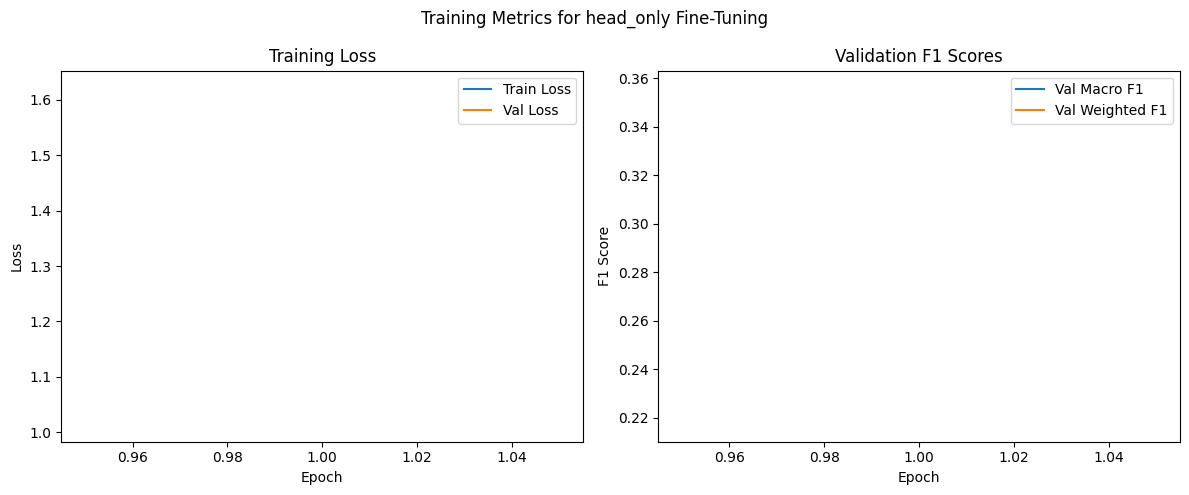

  >>> New best model saved!


Epoch 2/20 | Loss: 0.9614 | Val Loss: 1.4292 | Val Macro F1: 0.3269 | Val Weighted F1: 0.5122


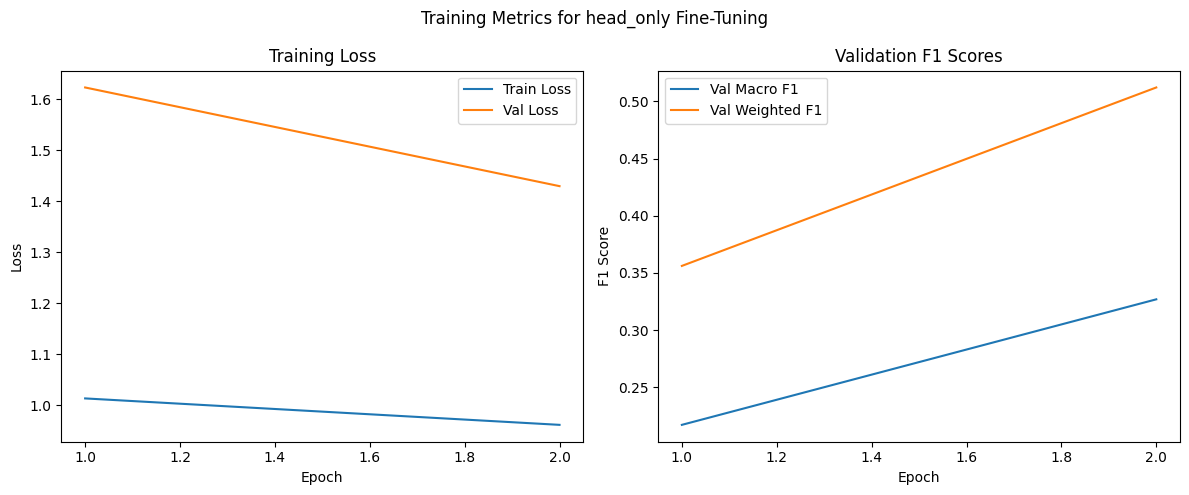

  >>> New best model saved!


Epoch 3/20 | Loss: 0.9401 | Val Loss: 1.4300 | Val Macro F1: 0.3415 | Val Weighted F1: 0.5407


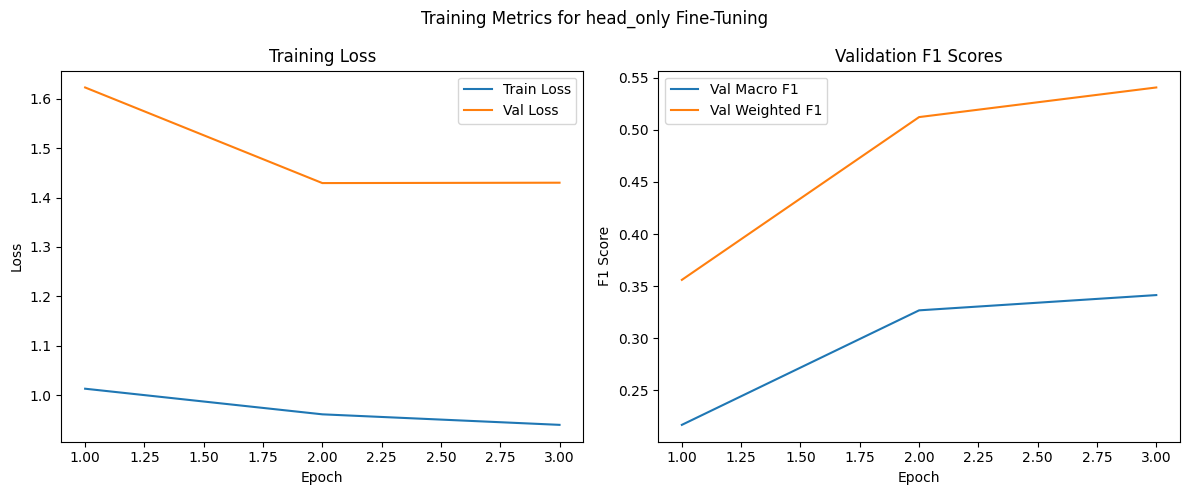

  >>> New best model saved!


KeyboardInterrupt: 

In [48]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_macro_f1': [],
    'val_weighted_f1': []
}
best_f1 = 0.0

for epoch in range(config['train']['epochs']):
    pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['train']['epochs']}", unit="batch", leave=False)
    train_loss = train_epoch(model, pbar_train, criterion, optimizer, device)

    val_loss, macro_f1, weight_f1, _ = evaluate(model, val_loader, criterion, device)
    
    print(f"Epoch {epoch+1}/{config['train']['epochs']} | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {macro_f1:.4f} | Val Weighted F1: {weight_f1:.4f}")
    history = plot_metrics(history, config, train_loss, val_loss, macro_f1, weight_f1)

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        torch.save(model.state_dict(), f"best_model_{config['model']['fine_tuning_mode']}.pth")
        print("  >>> New best model saved!")    